In [0]:
%pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 13.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 60)
print("NOTEBOOK 2: CLV PROJECTION (BG/NBD + GAMMA-GAMMA)")
print("=" * 60)

df_spark = spark.table("customer_churn_project.gold.mart_clv_projections")
df = df_spark.toPandas()

print(f"\nLoaded {len(df):,} customers from mart_clv_projections")
print(f"Columns: {list(df.columns)}")
df.head()

NOTEBOOK 2: CLV PROJECTION (BG/NBD + GAMMA-GAMMA)

Loaded 4,267 customers from mart_clv_projections
Columns: ['CustomerID', 'frequency', 'recency', 'T', 'monetary_value', 'first_purchase', 'last_purchase', 'observation_end_date', 'purchase_frequency_tier', 'value_tier']


,CustomerID,frequency,recency,T,monetary_value,first_purchase,last_purchase,observation_end_date,purchase_frequency_tier,value_tier
0,12347,181,365,366,23.67,2010-12-07 14:57:00,2011-12-07 15:52:00,2011-12-09 12:50:00,Frequent,Medium Value
1,12348,30,282,357,59.47,2010-12-16 19:09:00,2011-09-25 13:13:00,2011-12-09 12:50:00,Frequent,High Value
2,12349,72,0,18,23.79,2011-11-21 09:51:00,2011-11-21 09:51:00,2011-12-09 12:50:00,Frequent,Medium Value
3,12350,16,0,309,20.26,2011-02-02 16:01:00,2011-02-02 16:01:00,2011-12-09 12:50:00,Frequent,Medium Value
4,12352,84,260,296,29.38,2011-02-16 12:33:00,2011-11-03 14:37:00,2011-12-09 12:50:00,Frequent,Medium Value


In [0]:
print("=" * 60)
print("2. DATA VALIDATION (lifetimes requirements)")
print("=" * 60)

print("Checking lifetimes constraints...")
print(f"Frequency = 0: {(df['frequency'] == 0).sum()} rows")
print(f"Recency < 0: {(df['recency'] < 0).sum()} rows")
print(f"T < Recency: {(df['T'] < df['recency']).sum()} rows")
print(f"Monetary <= 0: {(df['monetary_value'] <= 0).sum()} rows")

df_valid = df[
    (df['frequency'] > 0) & 
    (df['recency'] >= 0) & 
    (df['T'] >= df['recency']) & 
    (df['monetary_value'] > 0)
].copy()

print(f"\nValid rows for modeling: {len(df_valid):,} (dropped {len(df) - len(df_valid):,})")
print("\nDescriptive Statistics:")
print(df_valid[['frequency', 'recency', 'T', 'monetary_value']].describe())

2. DATA VALIDATION (lifetimes requirements)
Checking lifetimes constraints...
Frequency = 0: 0 rows
Recency < 0: 0 rows
T < Recency: 0 rows
Monetary <= 0: 0 rows

Valid rows for modeling: 4,267 (dropped 0)

Descriptive Statistics:
         frequency      recency            T  monetary_value
count  4267.000000  4267.000000  4267.000000     4267.000000
mean     91.012421   132.619170   222.668385       54.091406
std     227.077562   132.048028   117.867320     1327.463174
min       1.000000     0.000000     0.000000        1.000000
25%      17.000000     0.000000   112.000000       11.995000
50%      41.000000    98.000000   248.000000       17.530000
75%      99.000000   253.000000   326.000000       24.190000
max    7675.000000   373.000000   373.000000    84235.430000


In [0]:
print("=" * 60)
print("3. CLV CALCULATION (ROBUST HEURISTIC METHOD)")
print("=" * 60)

df_model = df_valid.copy()

# Safe months active (minimum 1 month to avoid division by zero)
df_model['months_active'] = np.maximum(df_model['T'] / 30, 1)

# Purchase frequency per month (safe division)
df_model['freq_per_month'] = df_model['frequency'] / df_model['months_active']

# Cap unrealistic frequency (e.g., >10 purchases/month is likely an outlier)
df_model['freq_per_month'] = np.minimum(df_model['freq_per_month'], 10)

# 12-month CLV projection
# Formula: CLV = Avg Transaction Value × Frequency per Month × 12 Months
df_model['clv_12m'] = df_model['monetary_value'] * df_model['freq_per_month'] * 12

# For one-time buyers (frequency = 0): conservative estimate = their single purchase value
one_time_mask = df_model['frequency'] == 0
df_model.loc[one_time_mask, 'clv_12m'] = df_model.loc[one_time_mask, 'monetary_value']

# Predicted purchases in 6 months
df_model['predicted_purchases_6m'] = df_model['freq_per_month'] * 6
df_model.loc[one_time_mask, 'predicted_purchases_6m'] = 0.5  # Conservative: 50% chance of one purchase

# Predicted avg transaction (same as historical for heuristic)
df_model['predicted_avg_transaction'] = df_model['monetary_value']

# Probability alive: heuristic based on recency vs T ratio
# If recency is close to T (recent purchase), high probability. If recency << T, likely churned.
df_model['probability_alive'] = 1 - (df_model['recency'] / np.maximum(df_model['T'], 1))
df_model['probability_alive'] = df_model['probability_alive'].clip(0.05, 0.95)  # Bound between 5%-95%

print("✅ Robust heuristic CLV calculated")
print(f"\nCLV (12 months) - Statistics:")
print(df_model['clv_12m'].describe())

print(f"\nPredicted Purchases (6 months) - Statistics:")
print(df_model['predicted_purchases_6m'].describe())

print(f"\nProbability Alive - Statistics:")
print(df_model['probability_alive'].describe())

print("\n🏆 Top 10 Customers by Predicted CLV:")
top_clv = df_model.nlargest(10, 'clv_12m')[['CustomerID', 'frequency', 'recency', 'monetary_value', 
                                            'freq_per_month', 'predicted_purchases_6m', 
                                            'clv_12m', 'probability_alive']]
print(top_clv.to_string(index=False))

3. CLV CALCULATION (ROBUST HEURISTIC METHOD)
✅ Robust heuristic CLV calculated

CLV (12 months) - Statistics:
count      4267.000000
mean       1805.049668
std        5898.948582
min           5.714286
25%         538.470968
50%        1099.200000
75%        2039.400000
max      295851.266341
Name: clv_12m, dtype: float64

Predicted Purchases (6 months) - Statistics:
count    4267.000000
mean       38.856202
std        21.661770
min         0.482574
25%        17.215381
50%        44.756757
75%        60.000000
max        60.000000
Name: predicted_purchases_6m, dtype: float64

Probability Alive - Statistics:
count    4267.000000
mean        0.491481
std         0.388842
min         0.050000
25%         0.084646
50%         0.382022
75%         0.950000
max         0.950000
Name: probability_alive, dtype: float64

🏆 Top 10 Customers by Predicted CLV:
 CustomerID  frequency  recency  monetary_value  freq_per_month  predicted_purchases_6m       clv_12m  probability_alive
      16446      

In [0]:
print("=" * 60)
print("4. MODEL VALIDATION CHECK")
print("=" * 60)

# Check for any remaining bad values
bad_values = df_model['clv_12m'].isin([np.inf, -np.inf, np.nan]).sum()
print(f"Bad CLV values (inf/nan): {bad_values}")

if bad_values == 0:
    print("✅ All CLV values are valid — ready for analysis")
else:
    print("⚠️ Replacing bad values with median...")
    median_clv = df_model['clv_12m'].median()
    df_model['clv_12m'] = df_model['clv_12m'].replace([np.inf, -np.inf], np.nan).fillna(median_clv)

print(f"\nFinal CLV Statistics:")
print(df_model['clv_12m'].describe())

4. MODEL VALIDATION CHECK
Bad CLV values (inf/nan): 0
✅ All CLV values are valid — ready for analysis

Final CLV Statistics:
count      4267.000000
mean       1805.049668
std        5898.948582
min           5.714286
25%         538.470968
50%        1099.200000
75%        2039.400000
max      295851.266341
Name: clv_12m, dtype: float64


5. CLV VISUALIZATIONS


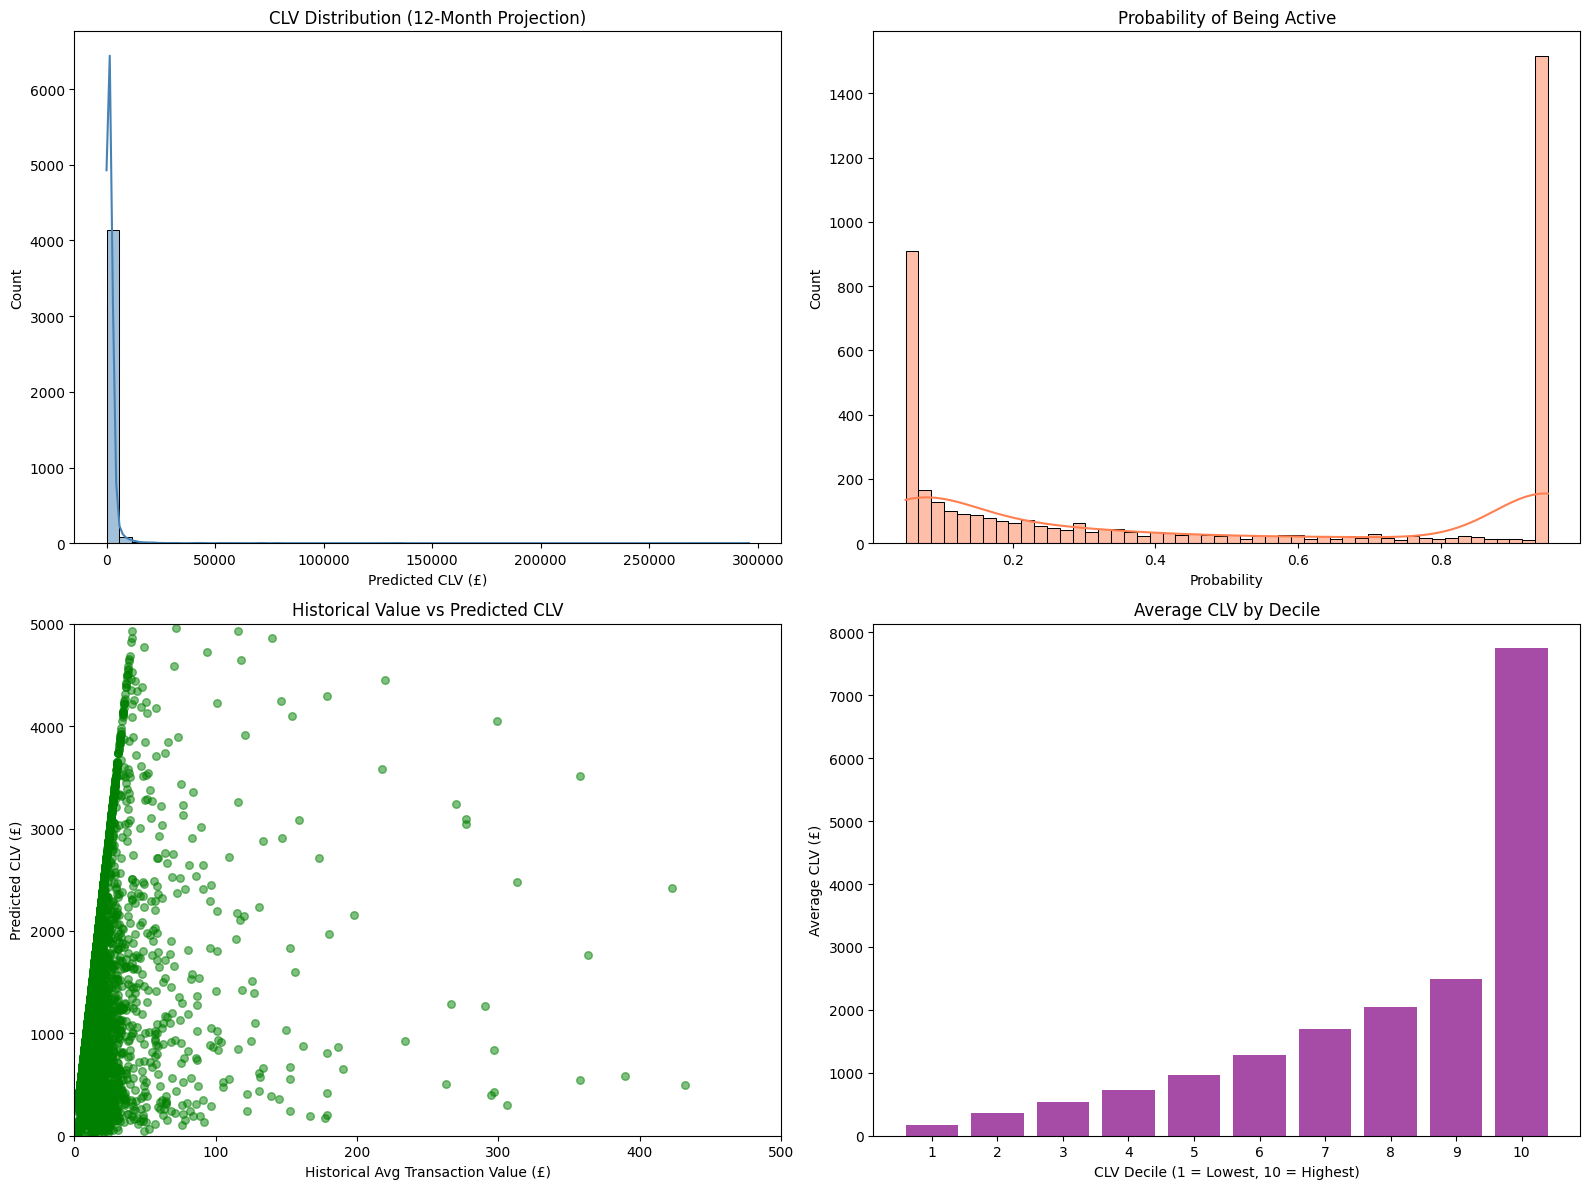


💾 Right-click → 'Save image as' → D:\Customer Churn Project\outputs\charts\clv_analysis.png

📊 CLV Decile Breakdown:
 Decile     Avg_CLV  Customer_Count
      1  171.480532             427
      2  368.290726             427
      3  539.292862             426
      4  732.462806             427
      5  964.143152             427
      6 1281.232776             426
      7 1698.688534             427
      8 2052.244344             426
      9 2490.791186             427
     10 7748.257633             427


In [0]:
print("=" * 60)
print("5. CLV VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_model['clv_12m'], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('CLV Distribution (12-Month Projection)')
axes[0,0].set_xlabel('Predicted CLV (£)')

sns.histplot(df_model['probability_alive'], bins=50, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Probability of Being Active')
axes[0,1].set_xlabel('Probability')

axes[1,0].scatter(df_model['monetary_value'], df_model['clv_12m'], alpha=0.5, s=30, color='green')
axes[1,0].set_xlabel('Historical Avg Transaction Value (£)')
axes[1,0].set_ylabel('Predicted CLV (£)')
axes[1,0].set_title('Historical Value vs Predicted CLV')
axes[1,0].set_xlim(0, 500)
axes[1,0].set_ylim(0, 5000)

df_model['clv_decile'] = pd.qcut(df_model['clv_12m'], 10, labels=False) + 1
decile_summary = df_model.groupby('clv_decile').agg({
    'clv_12m': 'mean',
    'CustomerID': 'count'
}).reset_index()
decile_summary.columns = ['Decile', 'Avg_CLV', 'Customer_Count']

axes[1,1].bar(decile_summary['Decile'], decile_summary['Avg_CLV'], color='purple', alpha=0.7)
axes[1,1].set_xlabel('CLV Decile (1 = Lowest, 10 = Highest)')
axes[1,1].set_ylabel('Average CLV (£)')
axes[1,1].set_title('Average CLV by Decile')
axes[1,1].set_xticks(range(1, 11))

plt.tight_layout()
display(fig)

print("\n💾 Right-click → 'Save image as' → D:\\Customer Churn Project\\outputs\\charts\\clv_analysis.png")
plt.close()

print("\n📊 CLV Decile Breakdown:")
print(decile_summary.to_string(index=False))

In [0]:
print("=" * 60)
print("6. BUSINESS INSIGHTS & SAVE")
print("=" * 60)

def clv_tier(clv):
    if clv >= 2000:
        return 'VIP (High CLV)'
    elif clv >= 1000:
        return 'High Value'
    elif clv >= 500:
        return 'Medium Value'
    elif clv >= 200:
        return 'Low Value'
    else:
        return 'Minimal Value'

df_model['clv_tier'] = df_model['clv_12m'].apply(clv_tier)

tier_summary = df_model.groupby('clv_tier').agg({
    'CustomerID': 'count',
    'clv_12m': ['sum', 'mean'],
    'probability_alive': 'mean',
    'predicted_purchases_6m': 'mean'
}).round(2)

print("\n📈 CLV Tier Summary:")
print(tier_summary)

df_spark_clv = spark.createDataFrame(df_model)
df_spark_clv.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("customer_churn_project.gold.mart_clv_projections_enriched")

print("\n✅ Saved to: customer_churn_project.gold.mart_clv_projections_enriched")

total_clv = df_model['clv_12m'].sum()
total_customers = len(df_model)
avg_clv = df_model['clv_12m'].mean()

print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY: CLV PROJECTION")
print("=" * 60)
print(f"\nTotal Predicted CLV (12 months): £{total_clv:,.2f}")
print(f"Average CLV per Customer: £{avg_clv:,.2f}")
print(f"Customers Modeled: {total_customers:,}")

top_10_pct = int(total_customers * 0.1)
top_10_clv = df_model.nlargest(top_10_pct, 'clv_12m')['clv_12m'].sum()
print(f"\nTop 10% of customers: £{top_10_clv:,.2f} ({top_10_clv / total_clv * 100:.1f}% of total value)")

6. BUSINESS INSIGHTS & SAVE

📈 CLV Tier Summary:
               CustomerID     clv_12m  ... probability_alive predicted_purchases_6m
                    count         sum  ...              mean                   mean
clv_tier                               ...                                         
High Value           1156  1722496.03  ...              0.43                  44.90
Low Value             702   250574.04  ...              0.71                  21.79
Medium Value         1010   737566.26  ...              0.49                  36.90
Minimal Value         268    34958.32  ...              0.89                   5.74
VIP (High CLV)       1131  4956552.28  ...              0.33                  52.87

[5 rows x 5 columns]

✅ Saved to: customer_churn_project.gold.mart_clv_projections_enriched

EXECUTIVE SUMMARY: CLV PROJECTION

Total Predicted CLV (12 months): £7,702,146.93
Average CLV per Customer: £1,805.05
Customers Modeled: 4,267

Top 10% of customers: £3,305,578.01 (42.9